# Predicting Heart Disease Risk with Deep Learning

This notebook builds a deep learning (MLP / feed-forward neural network) classifier that predicts whether a survey respondent has ever been told they have heart disease, using the **2020 BRFSS Heart Disease** dataset (`heart_2020_cleaned.csv`, ~320K respondents, 17 lifestyle/health features).

**Workflow**
1. Load & explore the data (EDA)
2. Clean & preprocess (encode categoricals, scale numerics)
3. Split into train/validation/test sets
4. Build a Keras MLP
5. Handle severe class imbalance (~8.6% positive class)
6. Train with early stopping
7. Evaluate with metrics suited to imbalanced classification (ROC-AUC, PR-AUC, F1, confusion matrix)
8. Inspect training curves and save the trained model


In [74]:
# %pip install tensorflow

In [75]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load the data

In [76]:
df = pd.read_csv("heart_2020_cleaned.csv")
print(df.shape)
df.head()


(319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [77]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [78]:
# Missing values check
df.isna().sum()


HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

## 3. Exploratory Data Analysis

In [79]:
target_counts = df["HeartDisease"].value_counts(normalize=True) * 100
print(target_counts)

plt.figure(figsize=(6, 3))
sns.countplot(x="HeartDisease", data=df, hue="HeartDisease", palette="viridis", legend=False)
plt.title("Class distribution: HeartDisease")
plt.ylabel("Count")
plt.show()

print(f"Positive class (Yes) makes up only {target_counts['Yes']:.1f}% of the data -> this is an imbalanced classification problem.")


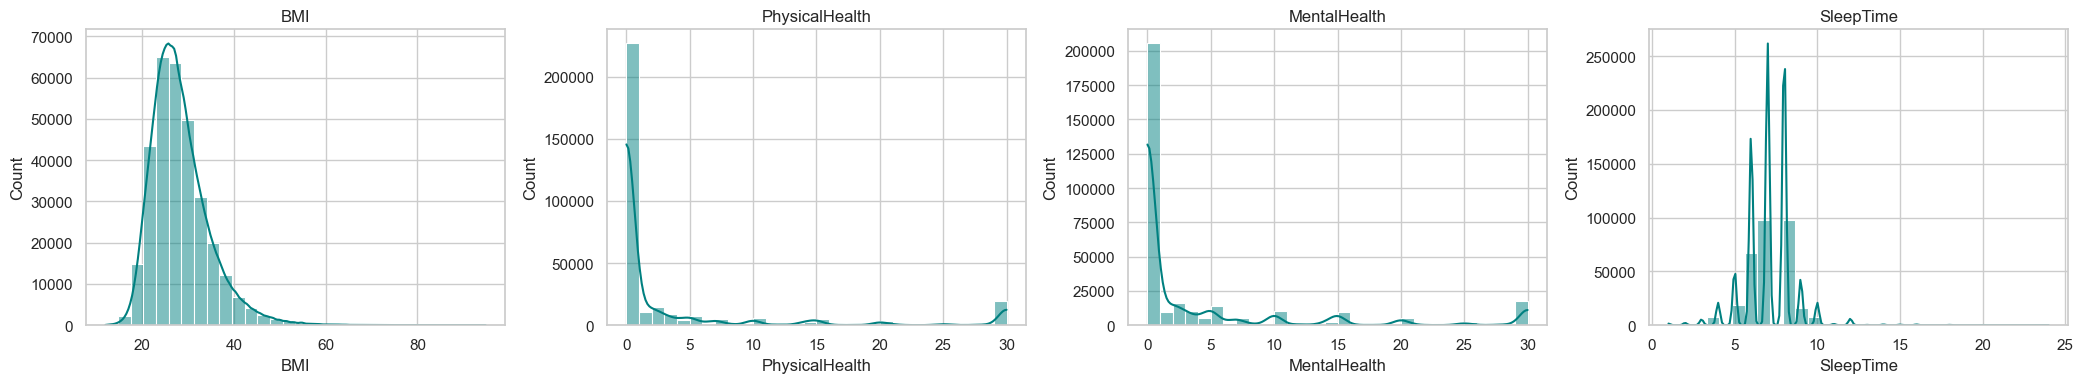

In [80]:
numeric_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

fig, axes = plt.subplots(1, 4, figsize=(21, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, ax=ax, kde=True, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()


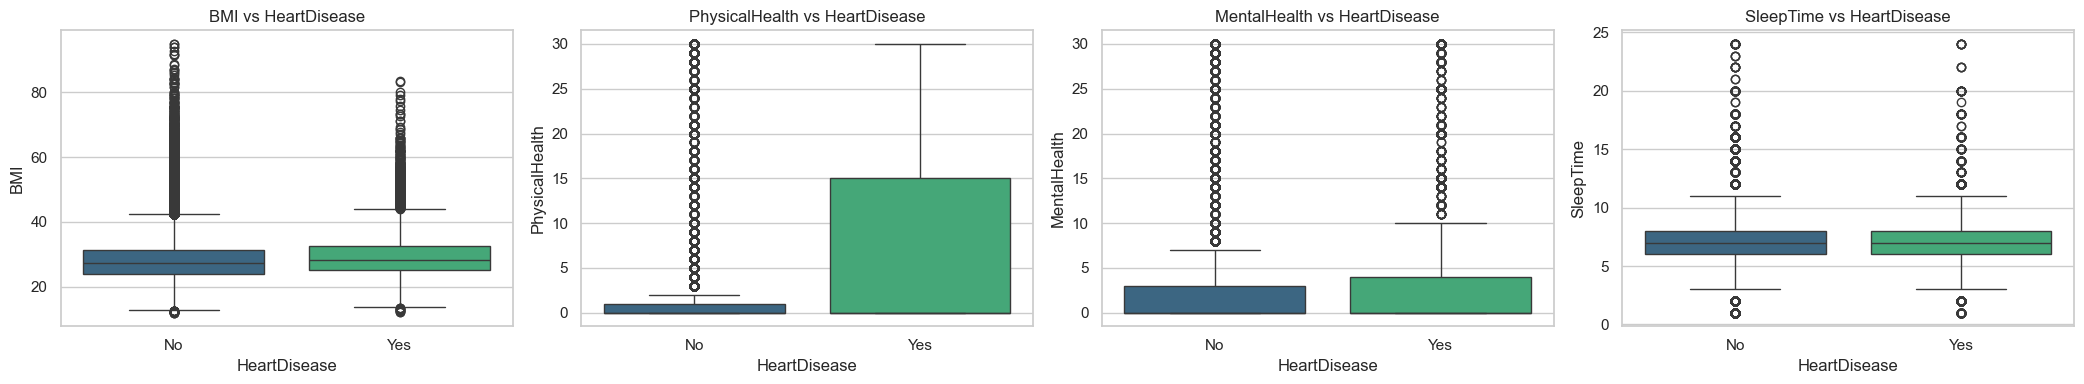

In [81]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="HeartDisease", y=col, data=df, hue="HeartDisease", ax=ax, palette="viridis", legend=False)
    ax.set_title(f"{col} vs HeartDisease")
plt.tight_layout()
plt.show()


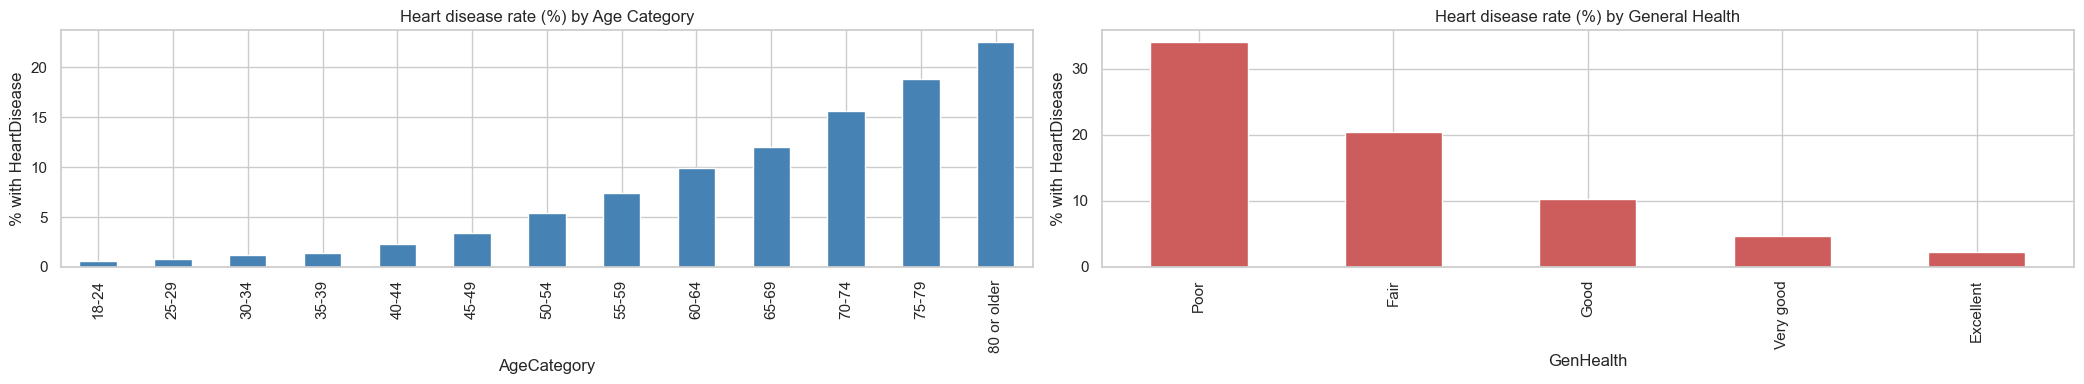

In [82]:
categorical_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking", "Sex",
                    "AgeCategory", "Race", "Diabetic", "PhysicalActivity",
                    "GenHealth", "Asthma", "KidneyDisease", "SkinCancer"]

# Heart disease rate by AgeCategory and GenHealth as two illustrative examples
fig, axes = plt.subplots(1, 2, figsize=(21, 4))

age_rate = df.groupby("AgeCategory")["HeartDisease"].apply(lambda s: (s == "Yes").mean() * 100).sort_index()
age_rate.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Heart disease rate (%) by Age Category")
axes[0].set_ylabel("% with HeartDisease")

genhealth_order = ["Poor", "Fair", "Good", "Very good", "Excellent"]
gh_rate = df.groupby("GenHealth")["HeartDisease"].apply(lambda s: (s == "Yes").mean() * 100).reindex(genhealth_order)
gh_rate.plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Heart disease rate (%) by General Health")
axes[1].set_ylabel("% with HeartDisease")

plt.tight_layout()
plt.show()


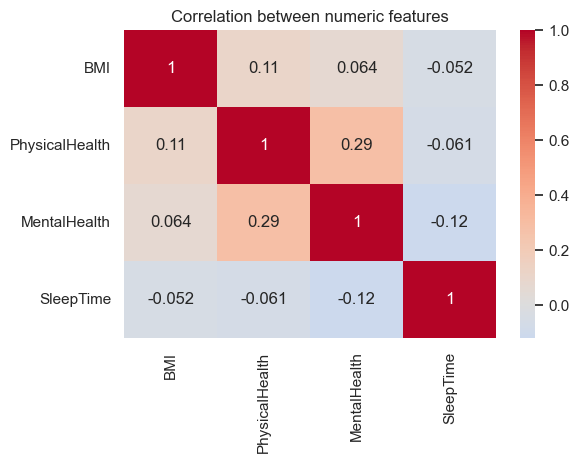

In [83]:
plt.figure(figsize=(6, 4))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()


## 4. Preprocessing

- Target `HeartDisease` (Yes/No) is mapped to 1/0.
- Numeric features are standardized (mean 0, std 1).
- Categorical features are one-hot encoded.
- Data is split 70% train / 15% validation / 15% test, using stratification to preserve the class ratio in every split.


In [84]:
y = (df["HeartDisease"] == "Yes").astype(int)
X = df.drop(columns=["HeartDisease"])

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


In [85]:
# 70/15/15 split, stratified on the target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Processed feature shape:", X_train_proc.shape)


Processed feature shape: (223856, 50)


## 5. Handle class imbalance

In [87]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight)


Class weights: {0: np.float64(0.5468037812354967), 1: np.float64(5.8414487761599085)}


## 6. Build the deep learning model

A feed-forward neural network (MLP) with:
- Two hidden blocks of `Dense -> BatchNorm -> ReLU -> Dropout`
- A sigmoid output for binary classification
- `class_weight` passed at training time to counteract the ~91/9 imbalance


In [88]:
n_features = X_train_proc.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 7. Train the model

In [89]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

history = model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)


875/875 - 5s - 6ms/step - auc: 0.8055 - loss: 0.5388 - pr_auc: 0.2806 - precision: 0.1917 - recall: 0.7749 - val_auc: 0.8420 - val_loss: 0.5234 - val_pr_auc: 0.3502 - val_precision: 0.1977 - val_recall: 0.8488 - learning_rate: 0.0010


Epoch 2/50


875/875 - 3s - 4ms/step - auc: 0.8336 - loss: 0.5027 - pr_auc: 0.3197 - precision: 0.2055 - recall: 0.8165 - val_auc: 0.8427 - val_loss: 0.5107 - val_pr_auc: 0.3526 - val_precision: 0.2000 - val_recall: 0.8453 - learning_rate: 0.0010


Epoch 3/50


875/875 - 4s - 4ms/step - auc: 0.8368 - loss: 0.4976 - pr_auc: 0.3252 - precision: 0.2081 - recall: 0.8248 - val_auc: 0.8423 - val_loss: 0.5059 - val_pr_auc: 0.3522 - val_precision: 0.2001 - val_recall: 0.8424 - learning_rate: 0.0010


...

Epoch 21/50


875/875 - 3s - 4ms/step - auc: 0.8450 - loss: 0.4851 - pr_auc: 0.3374 - precision: 0.2158 - recall: 0.8181 - val_auc: 0.8437 - val_loss: 0.4988 - val_pr_auc: 0.3552 - val_precision: 0.2117 - val_recall: 0.8200 - learning_rate: 6.2500e-05


Epoch 22/50


875/875 - 3s - 3ms/step - auc: 0.8447 - loss: 0.4854 - pr_auc: 0.3353 - precision: 0.2163 - recall: 0.8192 - val_auc: 0.8436 - val_loss: 0.4988 - val_pr_auc: 0.3552 - val_precision: 0.2121 - val_recall: 0.8190 - learning_rate: 6.2500e-05


Epoch 23/50


## 8. Training curves

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].set_title("ROC-AUC")
axes[1].legend()

axes[2].plot(history.history["pr_auc"], label="train")
axes[2].plot(history.history["val_pr_auc"], label="val")
axes[2].set_title("PR-AUC")
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Evaluate on the held-out test set

Because the positive class is rare (~8.6%), **accuracy alone is misleading** (a model predicting "No" for everyone would already be ~91% accurate). We focus on ROC-AUC, PR-AUC, recall, precision, and F1 for the positive class.


In [91]:
y_test_proba = model.predict(X_test_proc, verbose=0).ravel()

# Default 0.5 threshold
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("=== Classification report (threshold = 0.5) ===")
print(classification_report(y_test, y_test_pred, target_names=["No", "Yes"]))

roc_auc_val = roc_auc_score(y_test, y_test_proba)
pr_auc_val = average_precision_score(y_test, y_test_proba)
print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC (average precision): {pr_auc_val:.4f}")


=== Classification report (threshold = 0.5) ===
              precision    recall  f1-score   support

          No       0.98      0.71      0.83     43864
         Yes       0.21      0.82      0.34      4106

    accuracy                           0.72     47970
   macro avg       0.59      0.77      0.58     47970
weighted avg       0.91      0.72      0.78     47970

ROC-AUC: 0.8410
PR-AUC (average precision): 0.3495


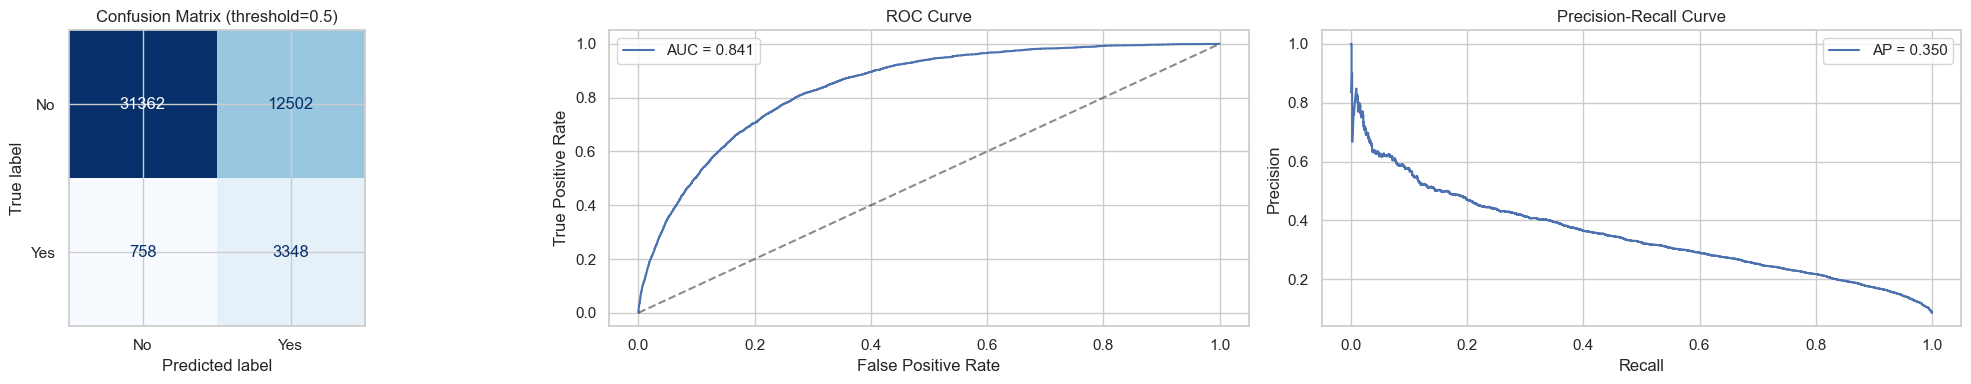

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(21, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (threshold=0.5)")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_val:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
axes[2].plot(rec, prec, label=f"AP = {pr_auc_val:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()


### Choosing a decision threshold

The default 0.5 threshold is not necessarily ideal for imbalanced, health-related screening tasks, where missing a true positive (false negative) is usually costlier than a false alarm. Below we scan thresholds and pick one that favors recall while keeping precision reasonable.


In [93]:
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []
for t in thresholds:
    pred = (y_test_proba >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    rows.append((t, precision, recall, f1))

thresh_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])
best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print(thresh_df.round(3))
print("\nBest F1 threshold:\n", best_row)


In [94]:
best_threshold = best_row["threshold"]
y_test_pred_best = (y_test_proba >= best_threshold).astype(int)

print(f"=== Classification report (threshold = {best_threshold:.2f}) ===")
print(classification_report(y_test, y_test_pred_best, target_names=["No", "Yes"]))


## 10. Save the trained model & preprocessing pipeline

In [95]:
import joblib
import os

os.makedirs("model", exist_ok=True)
model.save("model/heart_disease_mlp.keras")
joblib.dump(preprocessor, "model/preprocessor.joblib")
print("Saved model to model/heart_disease_mlp.keras")
print("Saved preprocessing pipeline to model/preprocessor.joblib")


## 11. Summary & next steps

- The MLP reaches a solid **ROC-AUC** and **PR-AUC** despite the ~91/9 class imbalance, thanks to `class_weight`, batch normalization, and dropout regularization.
- Since this is a health-screening-style task, **recall on the positive class** matters a lot — the threshold-scan above shows how precision and recall trade off, so you can pick an operating point matched to your use case (e.g. favor recall for a screening tool).
- **Possible extensions:**
  - Try oversampling techniques (SMOTE) instead of / in addition to class weights.
  - Hyperparameter tuning (Keras Tuner / Optuna) over layer sizes, dropout, learning rate.
  - Compare against classical baselines (logistic regression, gradient boosted trees) — on tabular data like this, trees often perform competitively with deep learning.
  - Add SHAP or permutation importance for model interpretability.
  - Calibrate predicted probabilities (Platt scaling / isotonic regression) if probability estimates will be used directly (e.g. for risk scores).
